In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from pathlib import Path

import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

#%matplotlib notebook
import matplotlib.pyplot as plt

# Added joblib used for saving the trained model
from joblib import dump, load

In [2]:
base_path = Path('./')

input_path = base_path.joinpath('../input_directory')
output_path = base_path.joinpath('../output_directory')

In [3]:
# TODO: ADD TEST TRAIN VAL SPLIT RIGHT HERE!

In [4]:
X = []
Y = []
age = []
sex = []

for mat_file in input_path.glob('*.mat'):
    print(mat_file, end = "\r")
    mat = loadmat(mat_file)['val'].astype('float32')
    #I dont't normalize the data on purpose; more on that later
    mat /= 1000 # convert to milliVolt scale
    X.append(mat)

    hea_file = mat_file.parent / (mat_file.stem + '.hea')
    #print(hea_file)
    
    #with hea_file.open() as f: #first line of file is different
        #print(f.readline()) 
    
    df = pd.read_csv(hea_file, sep = ' ', skiprows=1, index_col = 0, header = None) #use pandas to parse header
    Y.append( df.loc['#Dx:',1].split(',') )
    sex.append( df.loc['#Sex:',1] == 'Male' ) #Male == 1, Female == 0
    age.append( float(df.loc['#Age:',1]) )

age = np.clip(np.nan_to_num(np.array(age), nan = 60.),0,120) #replace bad values by guesses
sex = np.array(sex)
G = np.stack([age,sex], axis = 1).astype('float64') #additional features; some ages are negative???

t_min = min(x.shape[1] for x in X) #get minimum length in the dataset
t_min

3000

In [5]:
label_set = set() #find the set of different labels
for labels in Y:
    #if len(labels) >= 2: print(labels)
    for label in labels:
        label_set.add(label)

num_to_label = dict((idx,lab) for idx,lab in enumerate(label_set))
label_to_num = dict((lab,idx) for idx,lab in enumerate(label_set))

print(num_to_label)
print(label_to_num)
print(label_set)

{0: 'AF', 1: 'I-AVB', 2: 'RBBB', 3: 'PAC', 4: 'Normal', 5: 'STD', 6: 'STE', 7: 'LBBB', 8: 'PVC'}
{'AF': 0, 'I-AVB': 1, 'RBBB': 2, 'PAC': 3, 'Normal': 4, 'STD': 5, 'STE': 6, 'LBBB': 7, 'PVC': 8}
{'AF', 'I-AVB', 'RBBB', 'PAC', 'Normal', 'STD', 'STE', 'LBBB', 'PVC'}


In [6]:
#generate n out of k encoded array of labels
L = np.zeros((len(Y), len(label_set)), dtype = np.int8)
for idx, labels in enumerate(Y):
    for label in labels:
        L[idx, label_to_num[label]] = 1
L = np.array(L)

(256, 5)


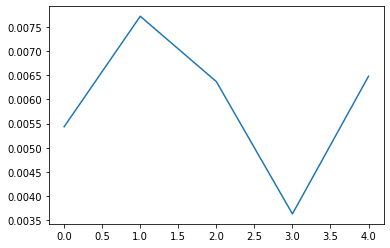

In [7]:
phi = np.array([-0.01011003, -0.0345178,  0.05892556,  0.2845178, 
                0.40236893, 0.2845178,  0.05892556, -0.0345178, -0.01011003])
psi = np.array([0.00505501+8.75554136e-03j, -0.0345178 -8.45442167e-18j,
                -0.02946278+5.10310353e-02j, -0.1422589 -2.46399639e-01j,
                0.40236893+0.00000000e+00j, -0.1422589 +2.46399639e-01j,
                -0.02946278-5.10310353e-02j, -0.0345178 +8.45442167e-18j,
                0.00505501-8.75554136e-03j])

# Scattering transform for real valued signals
def CDWT_scatter(x, depth, max_order, ax):
    def scatter(x): #compute only valid convolutions and one complex filter
        h = np.abs(  np.convolve(x, psi, mode='valid')[::2] )
        l = np.convolve(x, np.real(phi), mode='valid')[::2]

        return l, h

    #get the time coordinates of the filtered values
    ax_filter = np.zeros(phi.shape[0]) #make a delta filter with the same length as phi
    ax_filter[phi.shape[0]//2] = 1
    for i in range(depth): # this gets the same boundary as the scatter transform
        ax = np.convolve(ax, ax_filter, mode = 'valid')[::2]

    s = [x,]
    scatter_path = [[],]
    for i in range(depth):
        new_s = []
        new_scatter_path = []
        for L,x in zip(scatter_path,s):
            l,h = scatter(x)
            new_s.append(l)
            new_scatter_path.append(L+[0,])
            order = np.sum(L)
            if order < max_order:
                new_s.append(h)
                new_scatter_path.append(L+[1,])
        s = new_s
        scatter_path = new_scatter_path

    return np.array(s), scatter_path, ax

x = X[0][0,]
depth = 9
max_order = 4
scatter, path, ax = CDWT_scatter(x, depth, max_order, np.arange(len(x)))
print(scatter.shape)

plt.plot(scatter[1])
plt.show()

In [8]:
Z = []
for idx,x in enumerate(X):
    z = []
    for lead in x :
        scatter, path, ax = CDWT_scatter(lead, depth, max_order, np.arange(len(lead)))
        scatter = np.mean(scatter, axis = 1)#average over time
        z.append(scatter[1:]) #DO NOT USE DC - PART!
    z = np.array(z).flatten() #flatten the 12-lead dimension
    Z.append(z)
    print(idx, end = '   \r')
Z = np.array(Z)
Z.shape

(6877, 3060)

In [9]:
print(Z.shape, G.shape)

(6877, 3060) (6877, 2)


In [10]:
print(np.min(Z), np.max(Z))

-0.0035553905321760466 2.618756340369081


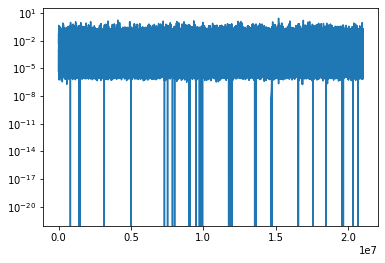

In [11]:
plt.semilogy(Z.flatten())
plt.show()

In [12]:
# Attention this is not common practice !!!! Never use test/validation set data for training...
# However we spoke about it and will use it for this test run!!!
# To compensate for it we will use values given here!!! This needs improvement


# After removing DC part all Z are positve -> log gives natural scale; numerical error causes negative values- > clip
Z2 = np.log(np.clip(Z,1e-8,np.inf))
# Remove mean per batch; this is equivalent to normalising the raw signal; remove the degree of freedom of the gain
print('mean1_Z', np.min(Z2, axis=1).shape)
Z2 -= Z2.mean(axis = 1, keepdims = True)
# Remove mean per dimension; this is to get all features to the same scale
z_mean = np.mean(Z2, axis=0, keepdims = True)
pickle.dump( z_mean, open('z_mean.bin','wb') )
Z2 -= z_mean

# G gets normalised per channel
print('mean0_G', G.mean(axis=0))
G2 = G - G.mean(axis = 0, keepdims = True)
print('std_G', G.std(axis=0))
G2 /= G2.std(axis = 0, keepdims = True)

# merge all features into one
F = np.concatenate([Z2,G2], 1)




mean1_Z (6877,)
mean0_G [60.16853279  0.53787989]
std_G [19.05683497  0.49856305]


In [13]:
L_train, L_tmp, F_train, F_tmp, = train_test_split(L,     F,     test_size=0.2, random_state=42)
L_test,  L_val, F_test,  F_val, = train_test_split(L_tmp, F_tmp, test_size=0.5, random_state=42)

print(len(L_train), len(L_test), len(L_val))

5501 688 688


In [14]:
clf = MultiOutputClassifier(LogisticRegression(multi_class = 'ovr', verbose=1, max_iter = 10000, C = 2**-1, warm_start=True))
clf.fit(F_train, L_train)

print(clf.score(F_train, L_train))
print(clf.score(F_test,  L_test ))

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.3s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.2s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 58.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.5s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   11.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_j

0.9123795673513907
0.5334302325581395


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.9s finished


In [15]:
np.array(clf.predict_proba(F_test))[:,:,1].shape

(9, 688)

In [16]:
F_train[0, :].shape

(3062,)

In [17]:
clf.classes_

[array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8),
 array([0, 1], dtype=int8)]

In [18]:
label_set

{'AF', 'I-AVB', 'LBBB', 'Normal', 'PAC', 'PVC', 'RBBB', 'STD', 'STE'}

In [19]:
np.array(clf.predict_proba(F_test[0, :][np.newaxis])).shape

(9, 1, 2)

# Exporting Test Scatter Network

In [20]:
# Preparations for physionet submission
# Save model to scattered.joblib 
dump(clf, 'scattered.joblib')

# Load model using joblib
model = load('scattered.joblib')

In [21]:
import io

# This will be the classifier we are going to use for the submission
def run_12ECG_classifier(data,header_data,classes,model):
    # Load the meta data 
    # Quick fix with io.StringIO such that jan can use pandas
    df = pd.read_csv(io.StringIO('\n'.join(header_data)),
                     sep = ' ', skiprows=1, index_col = 0,
                     header = None)
    sex = [df.loc['#Sex:',1] == 'Male']
    age = [float(df.loc['#Age:',1])]
    
    # Compute the features from the header
    age = np.clip(np.nan_to_num(np.array(age), nan = 60.),0,120)
    sex = np.array(sex)
    G = np.stack([age,sex], axis = 1).astype('float64')
    
    # TODO: For now do it this way (Pfusch)
    G = G - [60.16853279, 0.53787989]
    G = G / [19.05683497, 0.49856305]
    
    # Compute the scatter features
    Z = []
    for lead in data:
        scatter, path, ax = CDWT_scatter(lead, depth, max_order, np.arange(len(lead)))
        scatter = np.mean(scatter, axis = 1)
        Z.append(scatter[1:])
    Z = np.array(Z).flatten()[np.newaxis]

    # TODO: For now --> Jan said its fine this way
    Z = np.log(np.clip(Z,1e-8,np.inf))
    Z -= Z.mean(axis = 1, keepdims = True)
    
    z_mean = pickle.load(open('z_mean.bin','rb'))
    Z -= z_mean
    
    # Merge features
    F = np.concatenate([Z,G], 1)

    # TODO: Check if we want to have index 1 for axis 2 using model.classes_!!!
    current_label = model.predict(F)[0]
    current_score = np.array(model.predict_proba(F))[:, 0, 1]
    
    return(current_label, current_score)


In [22]:
# Offical function to load data that we need to use
import os
import tqdm
from driver import get_classes, load_challenge_data, save_challenge_predictions

input_directory = '../input_directory'
output_directory = '../output_directory'

# Method from pyhsionet guys
input_files = []
for f in os.listdir(input_directory):
    if os.path.isfile(os.path.join(input_directory, f)) and not \
        f.lower().startswith('.') and f.lower().endswith('mat'):
        input_files.append(f)

classes = get_classes(input_directory,input_files)

# Check if the classifier is still working
for i, f in tqdm.tqdm(enumerate(input_files)):
    tmp_input_file = os.path.join(input_directory, f)
    data, header_data = load_challenge_data(tmp_input_file)
    current_label, current_score = run_12ECG_classifier(data, header_data, classes, model)
    save_challenge_predictions(output_directory, f, current_score, current_label, classes)


6877it [11:57,  9.58it/s]


In [23]:
# Results SCATTER FIRST TRY
# AUROC|AUPRC|Accuracy|F-measure|Fbeta-measure|Gbeta-measure
# 0.367|0.086|0.656|0.076|0.112|0.036

In [24]:
# Results CNN
# AUROC|AUPRC|Accuracy|F-measure|Fbeta-measure|Gbeta-measure
#0.569|0.523|0.982|0.908|0.897|0.761

In [25]:
# Results SCATTER SECOND TRY
#AUROC|AUPRC|Accuracy|F-measure|Fbeta-measure|Gbeta-measure
#0.578|0.286|0.833|0.214|0.213|0.179